# Simulating dynamics using MPS+TEBD for the XY model:

$$H=J_z \sum_{n=1}^{L-1} \sigma_n^{z}\,\sigma_{n+1}^{z}+J_{\mathrm{long}} \sum_{n=1}^{L-1} \sigma_n^{x}\,\sigma_{n+1}^{x},$$

This model maps to the XY model

i.e. an NN (ZZ + XX) chain (often viewed as an anisotropic (XXZ) model with (J_y = 0)).


## 1. Importing libraries:

In [ ]:
%config InlineBackend.figure_formats = ['svg']
import numpy as np

import quimb as qu
import quimb.tensor as qtn

## 2. Initial state
Building an initial state using Quimb's Matrix product state (MPS)

In [ ]:
# -----------------------------
# System + initial state
# -----------------------------
L = 2
zeros = "0" * (L - 2)
binary = "0" + "1" + zeros
print("psi0:", f"|{binary}>")

psi0 = qtn.MPS_computational_state(binary)
psi0.show() 

## 3. Building the Hamiltonian

In `SpinHam1D` for spin $S = \tfrac{1}{2}$, the spin operators are defined as

$$
X \equiv S^x = \frac{\sigma^x}{2}, \qquad
Y \equiv S^y = \frac{\sigma^y}{2}, \qquad
Z \equiv S^z = \frac{\sigma^z}{2}.
$$

As a result, each two–spin interaction term carries an overall factor of $1/4$,
which explains the appearance of the extra prefactor in the Hamiltonian.


In [ ]:
# -----------------------------
# Hamiltonian:  H = Jz ZZ + Jlong XX   (nearest-neighbor only)
# -----------------------------
Jz = 1.0
Jlong = 1.0

builder = qtn.SpinHam1D(S=1/2)

# NOTE on conventions:
# SpinHam1D uses spin operators S^a (with eigenvalues ±1/2), not Pauli σ^a. :contentReference[oaicite:1]{index=1}
# If your couplings Jz, Jlong are meant for Pauli σ^a σ^a, use:
builder += 4 * Jz,   "Z", "Z"
builder += 4 * Jlong,"X", "X"
# If you instead interpret them as S^a S^a couplings, use the lines below as-is.
# builder += Jz,    "Z", "Z"   # NN ZZ
# builder += Jlong, "X", "X"   # NN XX

H = builder.build_local_ham(L)  # LocalHam1D suitable for TEBD  :contentReference[oaicite:2]{index=2}

Sanity check: build Hamiltonian both ways (LocalHam1D for TEBD, MPO→dense for checking)

In [ ]:
import numpy as np
import quimb.tensor as qtn

L = 2
Jz = 1.0
Jlong = 1.0

builder = qtn.SpinHam1D(S=1/2)
builder += 4 * Jz,    "Z", "Z"
builder += 4 * Jlong, "X", "X"

H_local = builder.build_local_ham(L)

H_mpo = builder.build_mpo(L)
H_quimb = H_mpo.to_dense()   # works in your version

# --- try to find the 4x4 bond term inside H_local ---
term_4x4 = None
where = None

for k, v in H_local.__dict__.items():
    if isinstance(v, dict):
        for kk, vv in v.items():
            if hasattr(vv, "shape") and vv.shape == (4, 4):
                term_4x4 = np.asarray(vv)
                where = (k, kk)
                break
    elif hasattr(v, "shape") and v.shape == (4, 4):
        term_4x4 = np.asarray(v)
        where = (k, None)

    if term_4x4 is not None:
        break

print("Found 4x4 term inside H_local:", term_4x4 is not None)
print("Location in __dict__:", where)

if term_4x4 is None:
    print("H_local.__dict__.keys() =", list(H_local.__dict__.keys()))
else:
    print("allclose(term_4x4, H_quimb) =", np.allclose(term_4x4, np.asarray(H_quimb)))
    print("eig(term_4x4) =", np.round(np.linalg.eigvalsh(term_4x4), 6))
    print("eig(H_quimb)  =", np.round(np.linalg.eigvalsh(np.asarray(H_quimb)), 6))


In [ ]:
# build MPO directly (this exists reliably)
H_mpo = builder.build_mpo(2)
H_quimb = H_mpo.to_dense()

print(H)
print("H_mpo = ", H_mpo)
print("H_quimb =\n", H_quimb)
print("Eigenvalues:", np.linalg.eigvalsh(H_quimb))


## 4. Using TEBD for time evolution

### Time-Evolving Block Decimation (TEBD)

In TEBD, the quantum state is represented as a matrix product state (MPS),
$$
|\psi\rangle
=
\sum_{\{\sigma\}}
A^{\sigma_1}_1
A^{\sigma_2}_2
\cdots
A^{\sigma_L}_L
|\sigma_1 \sigma_2 \cdots \sigma_L\rangle .
$$

The Hamiltonian is written as a sum of nearest-neighbor terms,
$$
H = \sum_n h_{n,n+1},
$$
which enables a Suzuki–Trotter decomposition of the time-evolution operator.
For a first-order Trotter step,
$$
e^{-i H \Delta t}
\approx
\prod_{n \in \mathrm{even}} e^{-i h_{n,n+1} \Delta t}
\prod_{n \in \mathrm{odd}} e^{-i h_{n,n+1} \Delta t}
+
\mathcal{O}(\Delta t^2).
$$

In `quimb.tensor` (qtn), each two-site gate is contracted into the MPS tensors
on sites $n$ and $n+1$, producing a joint tensor that is reshaped and split using
a singular value decomposition (SVD). The resulting tensors are truncated based
on a specified cutoff or maximum bond dimension, which controls entanglement
growth and numerical cost.

Even- and odd-bond updates are alternated at each time step, and the accuracy
of TEBD is governed by the Trotter order, the time step $\Delta t$, and the SVD
truncation error.


In [ ]:
# -----------------------------
# TEBD
# -----------------------------
tebd = qtn.TEBD(psi0, H)
tebd.split_opts["cutoff"] = 1e-12

ts = np.linspace(0, 80, 101)


sanity check

In [ ]:
import numpy as np
import quimb.tensor as qtn

L = 2
psi0 = qtn.MPS_computational_state("01")

Jz = 1.0
Jlong = 1.0

builder = qtn.SpinHam1D(S=1/2)
builder += 4 * Jz,    "Z", "Z"
builder += 4 * Jlong, "X", "X"
H = builder.build_local_ham(L)

tebd = qtn.TEBD(psi0.copy(), H, dt=0.01)
tebd.split_opts["cutoff"] = 0.0
tebd.split_opts["max_bond"] = 50

ts = [0.0, 0.1, 0.5, 1.0]
states = list(tebd.at_times(ts))

for t, psit in zip(ts, states):
    print(f"\n--- t = {t:.3f} ---")
    print("state =", np.array_str(psit.to_dense(), precision=6, suppress_small=True))

    info = {"cur_orthog": None}
    # magnetization() gives <S^z>; convert to Pauli <σ^z> = 2 <S^z>
    mz0 = 2 * psit.magnetization(0, info=info)
    mz1 = 2 * psit.magnetization(1, info=info)
    print(f"<σz0> = {mz0:+.6f}, <σz1> = {mz1:+.6f}")


## 5. Compute observables

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import quimb.tensor as qtn

# -----------------------------
# User settings
# -----------------------------
L = 5
Jz = 1.0
Jlong = 1.0

tmax = 1
nt = 10
ts = np.linspace(0.0, tmax, nt)

dt = 0.05          # TEBD trotter step (can reduce if needed)
tol = 1e-3         # target overall evolution tolerance
cutoff = 1e-12
max_bond = 512

# initial state |0 1 0 0 ... 0>
binary = "0" + "1" + "0" * (L - 2)
psi0 = qtn.MPS_computational_state(binary)

# reference site for correlations (the "1" in |0100...>)
i0 = 1

# -----------------------------
# Build Hamiltonian (Pauli convention via 4*J)
# H = Jz Σ σ^z_i σ^z_{i+1} + Jlong Σ σ^x_i σ^x_{i+1}
# SpinHam1D uses S = σ/2, hence 4*J factors
# -----------------------------
builder = qtn.SpinHam1D(S=1/2)
builder += 4 * Jz,    "Z", "Z"
builder += 4 * Jlong, "X", "X"
H = builder.build_local_ham(L)

# -----------------------------
# TEBD
# -----------------------------
tebd = qtn.TEBD(psi0.copy(), H, dt=dt)
tebd.split_opts["cutoff"] = cutoff
tebd.split_opts["max_bond"] = max_bond

# -----------------------------
# Helper: one-point <S^op_j> with fallbacks (version-safe-ish)
# -----------------------------
def one_point(psit, j, op, info=None):
    """
    Return <S^op_j> where op in {"X","Y","Z"}.
    Tries common quimb MPS methods across versions.
    """
    if hasattr(psit, "local_expectation"):
        return psit.local_expectation(j, op, info=info)
    if hasattr(psit, "site_expectation"):
        return psit.site_expectation(j, op, info=info)
    if hasattr(psit, "expectation"):
        return psit.expectation(j, op=op, info=info)

    # last-resort: some versions support correlation(i,i,op,op) giving <S^op S^op>,
    # but that's NOT <S^op>. So we refuse rather than silently doing something wrong.
    raise AttributeError(
        "Couldn't find a one-point expectation method on this MPS object.\n"
        "Try printing: [m for m in dir(psit) if 'expect' in m.lower()]\n"
        "and tell me what you see."
    )

# -----------------------------
# Collect observables
#   mz_pauli(t,j) = <σ^z_j>
#   Cxx_conn_pauli(t,j) = <σ^x_i0 σ^x_j> - <σ^x_i0><σ^x_j>
# -----------------------------
mz_t_j = np.zeros((nt, L), dtype=float)
cxx_conn_t_j = np.zeros((nt, L), dtype=float)

states = tebd.at_times(ts)

for it, psit in enumerate(states):
    info = {"cur_orthog": None}

    # magnetization profile (quimb magnetization gives <S^z>, convert -> <σ^z> = 2<S^z>
    for j in range(L):
        mz_t_j[it, j] = 2.0 * psit.magnetization(j, info=info)

    # connected xx correlations from i0 to all j
    # correlation() gives <S^x_i S^x_j>, convert connected -> Pauli by factor 4
    sx_i0 = one_point(psit, i0, "X", info=info)

    for j in range(L):
        sxsx = psit.correlation(i0, j, op1="X", op2="X", info=info)
        sx_j = one_point(psit, j, "X", info=info)
        conn_spin = sxsx - sx_i0 * sx_j
        cxx_conn_t_j[it, j] = 4.0 * conn_spin  # since σ=2S -> connected scales by 4

# -----------------------------
# Plot heatmaps (x=site, y=time)
# -----------------------------
extent = [0, L - 1, ts[0], ts[-1]]  # [xmin, xmax, ymin, ymax]

plt.figure()
plt.imshow(mz_t_j, aspect="auto", origin="lower", extent=extent)
plt.xlabel("site j")
plt.ylabel("time t")
plt.title(r"Magnetization heatmap $\,\langle \sigma^z_j(t)\rangle$")
plt.colorbar(label=r"$\langle \sigma^z\rangle$")
plt.tight_layout()
plt.show()

plt.figure()
plt.imshow(cxx_conn_t_j, aspect="auto", origin="lower", extent=extent)
plt.xlabel("site j")
plt.ylabel("time t")
plt.title(r"Connected correlator heatmap $\,C^{xx}_{i_0,j}(t)$ with $i_0=%d$" % i0)
plt.colorbar(label=r"$\langle \sigma^x_{i_0}\sigma^x_j\rangle - \langle \sigma^x_{i_0}\rangle\langle \sigma^x_j\rangle$")
plt.tight_layout()
plt.show()


# Jz Jlong

## XY model

psi0: |1011111111>
 1 1 1 1 1 1 1 1 1 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


t=1, max-bond=32: 100%|##########| 101/101 [00:02<00:00, 35.82it/s]   


TEBD err: 4.472135954999578e-08


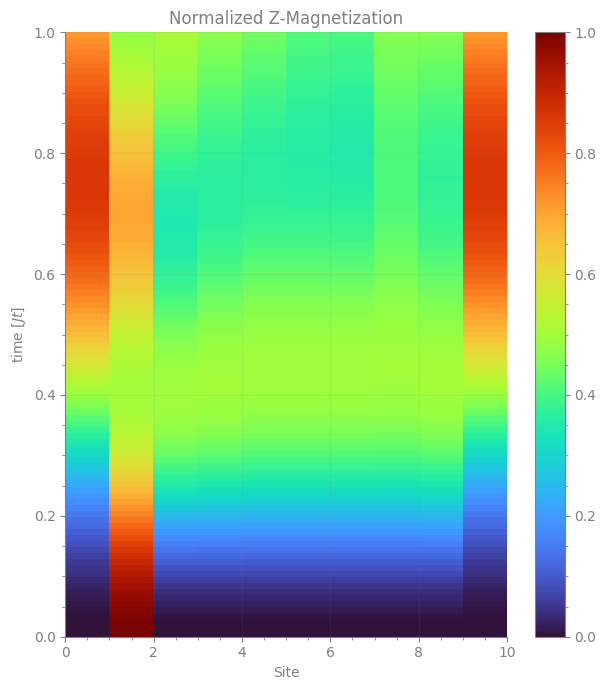

In [7]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# Setup
# -----------------------------
L = 10
tmax = 1
numIntervals=100
ones = "1" * (L - 2)
binary = "1" + "0" + ones
print("psi0:", f"|{binary}>")

psi0 = qtn.MPS_computational_state(binary)
psi0.show()

##########################################################
# Heisenberg NN Hamiltonian
# H = qtn.ham_1d_heis(L)


Sx = qu.spin_operator('x', S=1/2)


#TFIM Hamiltonian
Jz=1
Jshort=2

builder = qtn.SpinHam1D(S=1/2)
builder += 4 * Jz,    "Z","Z"
builder += 4 * Jshort, "X", "X"
H = builder.build_local_ham(L)

# #Jz, Jlong hamiltonian
# Jz=1
# Jlong=2
# ## Hamiltonian builder
# builder = qtn.SpinHam1D(S=1/2)
# builder += 4 * Jz,    "Z", "Z"
# builder += 4 * Jlong, "X", "X"
# H = builder.build_local_ham(L)

##########################################################

# TEBD engine
tebd = qtn.TEBD(psi0, H)

# TEBD split / truncation settings
tebd.split_opts["cutoff"] = 1e-12

# times we are interested in
ts = np.linspace(0, tmax, numIntervals+1)

# collect magnetization vs (t, site)
mz_t_j = []
info = {"cur_orthog": None}

for psit in tebd.at_times(ts, tol=1e-3):
    mz_j = [psit.magnetization(0, info=info)]
    for j in range(1, L):
        mz_j.append(psit.magnetization(j, info=info))
    mz_t_j.append(mz_j)

mz_t_j = np.asarray(mz_t_j)

# -----------------------------
# Normalize magnetization
# [-1/2, 1/2] -> [0, 1]
# -----------------------------
mz_norm = np.real(mz_t_j) + 0.5

# TEBD error check
print("TEBD err:", tebd.err)

# -----------------------------
# Plot
# -----------------------------
with plt.style.context(qu.NEUTRAL_STYLE):
    plt.figure(figsize=(12, 7))

    # --- Linear scale normalized magnetization ---
    ax1 = plt.subplot(121)
    im1 = plt.imshow(
        mz_norm,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
        extent=[0, L, ts[0], ts[-1]],
        rasterized=True,
    )
    plt.colorbar(im1, ax=ax1)
    ax1.set_title("Normalized Z-Magnetization")
    ax1.set_xlabel("Site")
    ax1.set_ylabel(r"time [$Jt$]")

    plt.tight_layout()
    plt.show()


## TFIM

psi0: |10111111111111111111111111111111111111111111111101>
     1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1    
... >─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─>─ ...
    │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │ │     
                                 ...                                  
     1 1 1 1 1 1 1 1 1 1 1 1 1 1 
    >─>─>─>─>─>─>─>─>─>─>─>─>─>─●
    │ │ │ │ │ │ │ │ │ │ │ │ │ │ │


t=5, max-bond=32: 100%|##########| 101/101 [00:26<00:00,  3.88it/s]   


TEBD err: 0.0001270545448800147


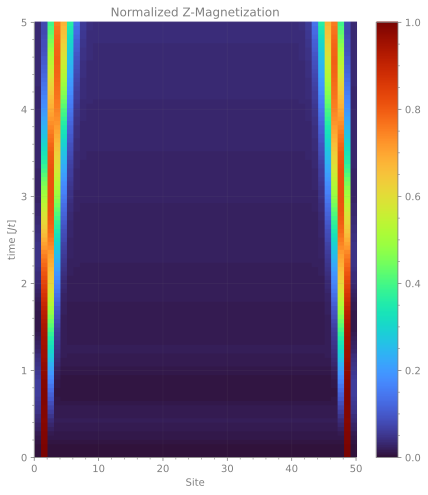

In [97]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# Setup
# -----------------------------
L = 50
tmax = 5
numIntervals=100
ones = "1" * (L - 4)
binary = "1" + "0" + ones +"0" + "1"
print("psi0:", f"|{binary}>")

psi0 = qtn.MPS_computational_state(binary)
psi0.show()

##########################################################
# Heisenberg NN Hamiltonian
# H = qtn.ham_1d_heis(L)


Sx = qu.spin_operator('x', S=1/2)


#TFIM Hamiltonian
B=0.5
Jshort=2

builder = qtn.SpinHam1D(S=1/2)
builder += 2 * B,    "X"
builder += 4 * Jshort, "Z", "Z"
H = builder.build_local_ham(L)

# #Jz, Jlong hamiltonian
# Jz=1
# Jlong=2
# ## Hamiltonian builder
# builder = qtn.SpinHam1D(S=1/2)
# builder += 4 * Jz,    "Z", "Z"
# builder += 4 * Jlong, "X", "X"
# H = builder.build_local_ham(L)

##########################################################

# TEBD engine
tebd = qtn.TEBD(psi0, H)

# TEBD split / truncation settings
tebd.split_opts["cutoff"] = 1e-12

# times we are interested in
ts = np.linspace(0, tmax, numIntervals+1)

# collect magnetization vs (t, site)
mz_t_j = []
info = {"cur_orthog": None}

for psit in tebd.at_times(ts, tol=1e-3):
    mz_j = [psit.magnetization(0, info=info)]
    for j in range(1, L):
        mz_j.append(psit.magnetization(j, info=info))
    mz_t_j.append(mz_j)

mz_t_j = np.asarray(mz_t_j)

# -----------------------------
# Normalize magnetization
# [-1/2, 1/2] -> [0, 1]
# -----------------------------
mz_norm = np.real(mz_t_j) + 0.5

# TEBD error check
print("TEBD err:", tebd.err)

# -----------------------------
# Plot
# -----------------------------
with plt.style.context(qu.NEUTRAL_STYLE):
    plt.figure(figsize=(12, 7))

    # --- Linear scale normalized magnetization ---
    ax1 = plt.subplot(121)
    im1 = plt.imshow(
        mz_norm,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
        extent=[0, L, ts[0], ts[-1]],
        rasterized=True,
    )
    plt.colorbar(im1, ax=ax1)
    ax1.set_title("Normalized Z-Magnetization")
    ax1.set_xlabel("Site")
    ax1.set_ylabel(r"time [$Jt$]")

    plt.tight_layout()
    plt.show()


psi0: |1011111111>
 1 1 1 1 1 1 1 1 1 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


t=1, max-bond=8: 100%|##########| 101/101 [00:04<00:00, 20.44it/s]  


TEBD err: 4.082306475460447e-08
max |Im <Sz_i Sz_j>| = 0.0


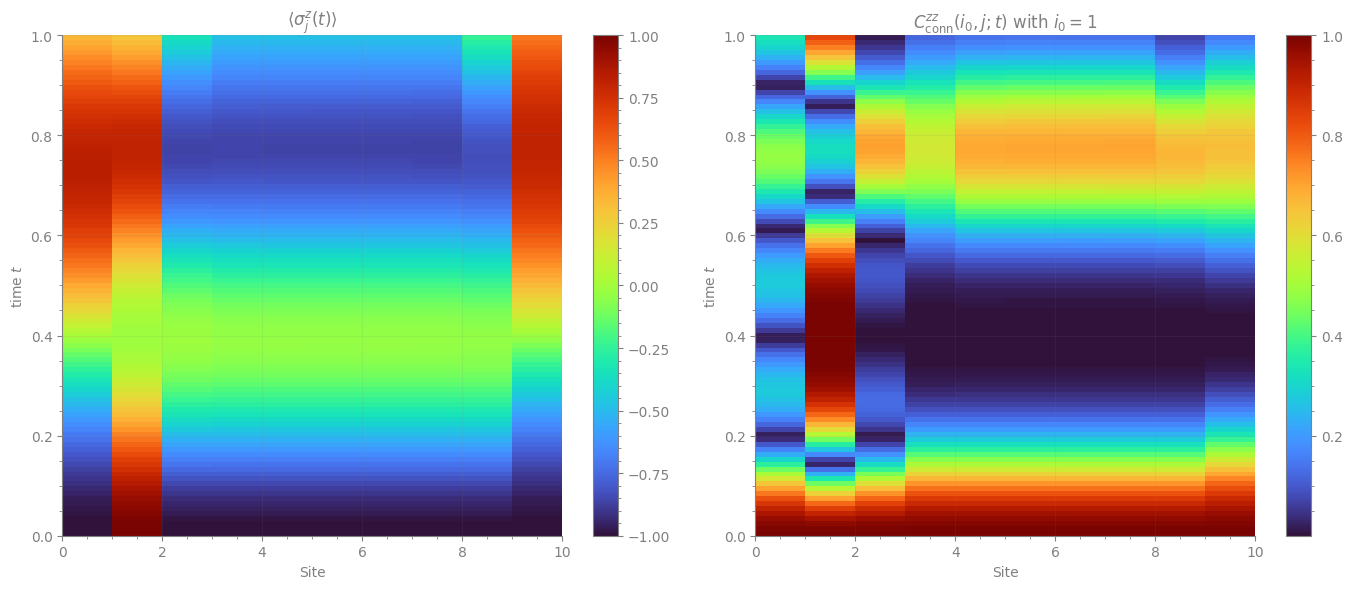

In [ ]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt

# -----------------------------
# Setup
# -----------------------------
L = 10
tmax = 1
numIntervals = 100

ones = "1" * (L - 4)
binary = "1" + "0" + ones + "1" + "1"
print("psi0:", f"|{binary}>")

psi0 = qtn.MPS_computational_state(binary)
psi0.show()

# local spin operator (S = σ/2)
Sz = qu.spin_operator('z', S=1/2)

# -----------------------------
# TFIM Hamiltonian
# H = B Σ σ^x + J Σ σ^z σ^z
# SpinHam1D uses S = σ/2 so use 2B and 4J
# -----------------------------
B = -0.5
Jshort = -2.0

builder = qtn.SpinHam1D(S=1/2)
builder += 2 * B, "Z"
builder += 4 * Jshort, "X", "X"
H = builder.build_local_ham(L)

# -----------------------------
# TEBD
# -----------------------------
tebd = qtn.TEBD(psi0, H)
tebd.split_opts["cutoff"] = 1e-12

ts = np.linspace(0, tmax, numIntervals + 1)

# choose a reference site for the correlation heatmap
i0 = 1  # change if you want (e.g., 1 or L//2)

# storage: (time, site)
mz_t_j = np.zeros((len(ts), L), dtype=float)          # <σ^z_j>
czzc_t_j = np.zeros((len(ts), L), dtype=float)        # connected <σ^z_i0 σ^z_j>_c

max_imag = 0.0

for it, psit in enumerate(tebd.at_times(ts, tol=1e-3)):
    info = {"cur_orthog": None}

    # --- z magnetization profile ---
    # magnetization() gives <S^z>, convert to Pauli <σ^z> = 2 <S^z>
    mz_spin = np.zeros(L, dtype=float)
    for j in range(L):
        mz_spin[j] = float(np.real(psit.magnetization(j, info=info)))  # <S^z_j>
        mz_t_j[it, j] = 2.0 * mz_spin[j]                               # <σ^z_j>

    # --- connected zz correlator from i0 to all j ---
    # correlation(Sz, i0, j, Sz) gives <S^z_i0 S^z_j>
    mi = mz_spin[i0]
    for j in range(L):
        szz = psit.correlation(Sz, i0, j, Sz)
        max_imag = max(max_imag, abs(np.imag(szz)))
        szz = np.real(szz)

        conn_spin = szz - mi * mz_spin[j]      # <S^z_i S^z_j> - <S^z_i><S^z_j>
        czzc_t_j[it, j] = np.abs(4.0 * conn_spin)      # convert to Pauli: σσ = 4 SS

print("TEBD err:", tebd.err)
print("max |Im <Sz_i Sz_j>| =", max_imag)

# -----------------------------
# Plot heatmaps
# -----------------------------
extent = [0, L, ts[0], ts[-1]]

with plt.style.context(qu.NEUTRAL_STYLE):
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(121)
    im1 = plt.imshow(
        mz_t_j + 0.0,  # already in [-1,1]
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        extent=extent,
        rasterized=True,
    )
    plt.colorbar(im1, ax=ax1)
    ax1.set_title(r"$\langle \sigma^z_j(t)\rangle$")
    ax1.set_xlabel("Site")
    ax1.set_ylabel(r"time $t$")

    ax2 = plt.subplot(122)
    im2 = plt.imshow(
        czzc_t_j,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        interpolation="nearest",
        extent=extent,
        rasterized=True,
    )
    plt.colorbar(im2, ax=ax2)
    ax2.set_title(r"$C^{zz}_{\mathrm{conn}}(i_0,j;t)$ with $i_0=%d$" % i0)
    ax2.set_xlabel("Site")
    ax2.set_ylabel(r"time $t$")

    plt.tight_layout()
    plt.show()


# Example code from Quimb

psi0: |1011111111>
 1 1 1 1 1 1 1 1 1 
>─>─>─>─>─>─>─>─>─●
│ │ │ │ │ │ │ │ │ │


t=10, max-bond=2: 100%|##########| 101/101 [00:02<00:00, 39.37it/s]


TEBD err: 0.000866025403784438


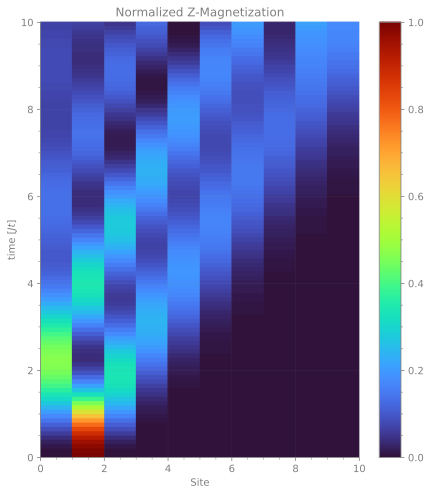

In [77]:
import numpy as np
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# -----------------------------
# Setup
# -----------------------------
L = 10
ones = "1" * (L - 2)
binary = "1" + "0" + ones
print("psi0:", f"|{binary}>")

psi0 = qtn.MPS_computational_state(binary)
psi0.show()

##########################################################
# Heisenberg NN Hamiltonian
H = qtn.ham_1d_heis(L)

##########################################################

# TEBD engine
tebd = qtn.TEBD(psi0, H)

# TEBD split / truncation settings
tebd.split_opts["cutoff"] = 1e-12

# times we are interested in
ts = np.linspace(0, 10, 101)

# collect magnetization vs (t, site)
mz_t_j = []
info = {"cur_orthog": None}

for psit in tebd.at_times(ts, tol=1e-3):
    mz_j = [psit.magnetization(0, info=info)]
    for j in range(1, L):
        mz_j.append(psit.magnetization(j, info=info))
    mz_t_j.append(mz_j)

mz_t_j = np.asarray(mz_t_j)

# -----------------------------
# Normalize magnetization
# [-1/2, 1/2] -> [0, 1]
# -----------------------------
mz_norm = np.real(mz_t_j) + 0.5

# TEBD error check
print("TEBD err:", tebd.err)

# -----------------------------
# Plot (imshow, no white gridlines)
# -----------------------------
with plt.style.context(qu.NEUTRAL_STYLE):
    plt.figure(figsize=(12, 7))

    # --- Linear scale normalized magnetization ---
    ax1 = plt.subplot(121)
    im1 = plt.imshow(
        mz_norm,
        aspect="auto",
        origin="lower",
        cmap="turbo",
        vmin=0.0,
        vmax=1.0,
        interpolation="nearest",
        extent=[0, L, ts[0], ts[-1]],
        rasterized=True,
    )
    plt.colorbar(im1, ax=ax1)
    ax1.set_title("Normalized Z-Magnetization")
    ax1.set_xlabel("Site")
    ax1.set_ylabel(r"time [$Jt$]")

    plt.tight_layout()
    plt.show()
